In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_excel('Real_estate.xlsx')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


No nulls shown can just continue then 

In [5]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [6]:
df.corr()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048634,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048634,1.000000,0.017542,0.060880,0.009544,0.035016,-0.041065,0.087529
X2 house age,-0.032808,0.017542,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009544,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035016,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041065,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087529,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


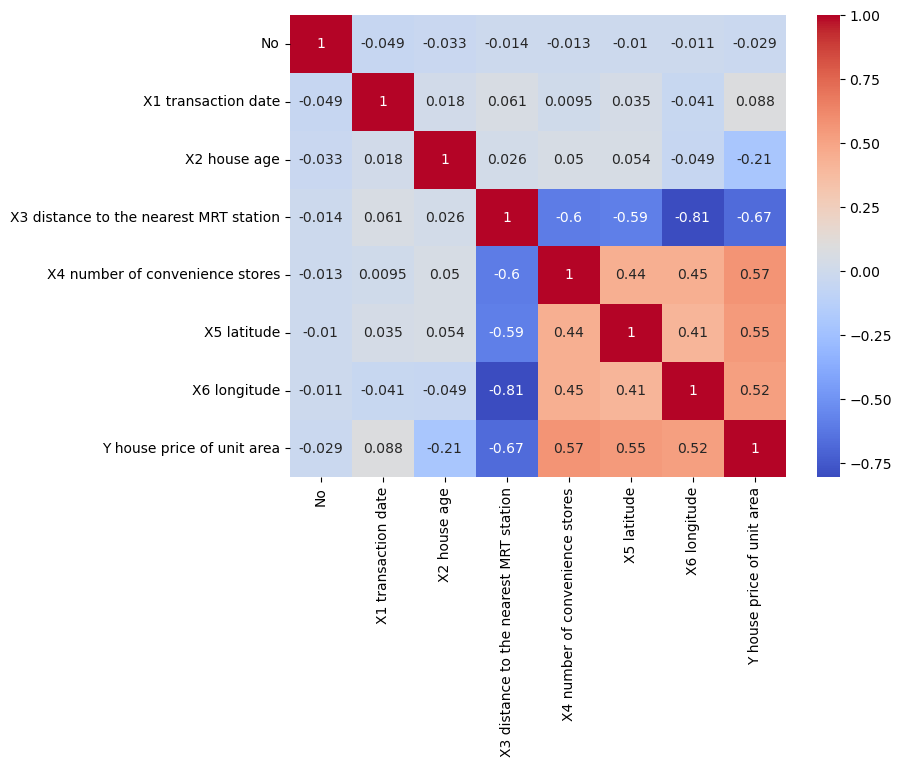

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [8]:
X = df.drop(['Y house price of unit area', 'No'], axis = 1)
y = df['Y house price of unit area'] 


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state=42)

In [10]:
linmodel = Pipeline([
    ('s', StandardScaler()),
    ('model', LinearRegression())
])
linear_step = linmodel.named_steps['model']

In [11]:
#notes forgot to originally scale the model seems to help the model due to longitude numbers being too big and messing with the prediction

In [12]:
linmodel.fit(X_train,y_train)

,steps,"[('s', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [13]:
lin_pred = linmodel.predict(X_test)

In [14]:
coef_df_lin1 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_step.coef_
})

print(coef_df_lin1)

                                  Feature  Coefficient
0                     X1 transaction date     1.530451
1                            X2 house age    -3.062726
2  X3 distance to the nearest MRT station    -5.786979
3         X4 number of convenience stores     3.219002
4                             X5 latitude     2.855183
5                            X6 longitude    -0.441170


In [15]:
def view_coeff(X, model):
    model_coefs = pd.DataFrame({'variable': X.columns,
                                'coef': model.coef_,
                                'abs_coef': np.abs(model.coef_)})
    model_coefs.sort_values('abs_coef', inplace=True, ascending=False)
    sns.barplot(x="variable", y="coef", data=model_coefs)
    plt.xticks(rotation=95)
    plt.show()

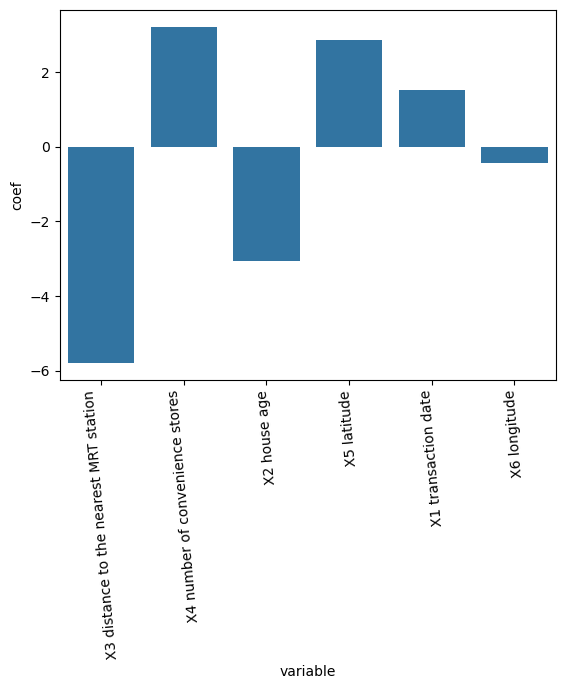

In [16]:
view_coeff(X ,linear_step)

In [17]:
rmse_lin1 = np.sqrt(mean_squared_error(y_test, lin_pred))
mae_lin1 = mean_absolute_error(y_test, lin_pred)
r2_lin1 = r2_score(y_test, lin_pred)

print(f"RMSE: {rmse_lin1:.3f}")
print(f"MAE: {mae_lin1:.3f}")
print(f"R²: {r2_lin1:.3f}")

RMSE: 7.315
MAE: 5.305
R²: 0.681


Linear Regression doesnt seem to be doing the best 
(btw tried to do it without coordinates just made the model worse so kept it in)

Trying both ridge and lasso 

In [18]:
ridgemodel = Pipeline([
    ('s', StandardScaler()),
    ('model', RidgeCV())
])
ridge_step = ridgemodel.named_steps['model']

lassomodel = Pipeline([
    ('s', StandardScaler()),
    ('model', Lasso())
])

lasso_step = lassomodel.named_steps['model']

In [19]:
ridgemodel.fit(X_train,y_train)
lassomodel.fit(X_train,y_train)

,steps,"[('s', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True


In [20]:
ridge_pred = ridgemodel.predict(X_test)
lasso_pred = lassomodel.predict(X_test)

RIDGE RESULTS

In [21]:
coef_df_r1 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_step.coef_
})

print('Ridge' ,coef_df_r1)

Ridge                                   Feature  Coefficient
0                     X1 transaction date     1.466623
1                            X2 house age    -2.967250
2  X3 distance to the nearest MRT station    -5.309401
3         X4 number of convenience stores     3.231093
4                             X5 latitude     2.888470
5                            X6 longitude    -0.076175


In [22]:
rmse_r1 = np.sqrt(mean_squared_error(y_test, ridge_pred))
mae_r1 = mean_absolute_error(y_test, ridge_pred)
r2_r1 = ridgemodel.score(X_test,y_test)

print(f"RMSE: {rmse_r1:.3f}")
print(f"MAE: {mae_r1:.3f}")
print(f"R²: {r2_r1:.3f}")

RMSE: 7.286
MAE: 5.295
R²: 0.684


In [23]:
r2 = ridgemodel.score(X_test, y_test)
n, p = X.shape

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2

0.6789275470166495

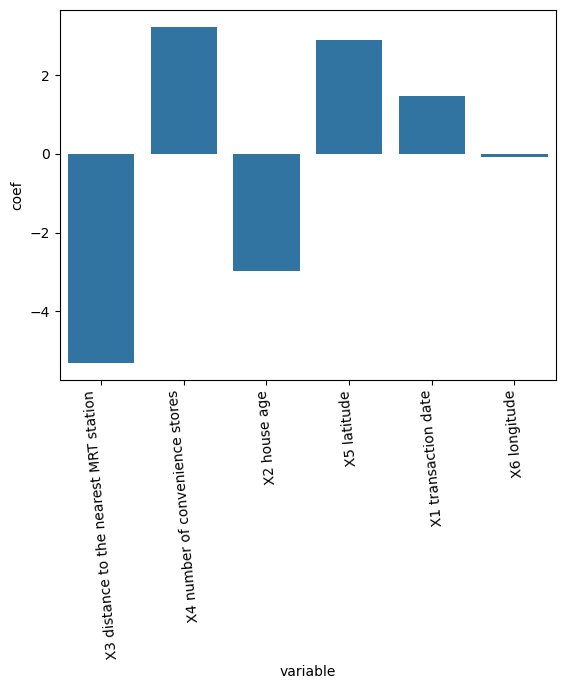

In [24]:
view_coeff(X ,ridge_step)

LASSO RESULTS 

In [25]:
coef_df_lasso1 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_step.coef_
})

print('Lasso' ,coef_df_lasso1)

Lasso                                   Feature  Coefficient
0                     X1 transaction date     0.473679
1                            X2 house age    -2.002817
2  X3 distance to the nearest MRT station    -5.066341
3         X4 number of convenience stores     2.622114
4                             X5 latitude     2.312947
5                            X6 longitude     0.000000


In [26]:
rmse_lasso1 = np.sqrt(mean_squared_error(y_test, lasso_pred))
mae_lasso1 = mean_absolute_error(y_test, lasso_pred)
r2_lasso1 = lassomodel.score(X_test,y_test)

print(f"RMSE: {rmse_lasso1:.3f}")
print(f"MAE: {mae_lasso1:.3f}")
print(f"R²: {r2_lasso1:.3f}")


RMSE: 7.469
MAE: 5.635
R²: 0.667


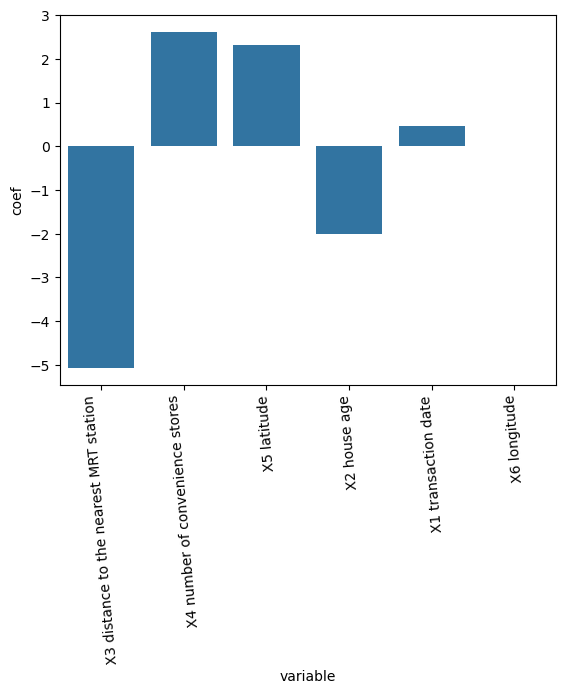

In [27]:
view_coeff(X ,lasso_step)

Linear r2 : 0.681
Ridge r2 : 0.684
Lasso r2 : 0.667

Trying random forest regressor 

In [28]:
#cant use random forest regressor for miniproject 2 also prob over fitting 

In [29]:
rf = RandomForestRegressor(
    n_estimators=100,       # Number of trees
    max_depth=None,         # Let trees grow until all leaves are pure
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

In [30]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
rf.score(X_train,y_train)

0.9500237986521518

Gonna try use all the models again but with some different variables for example no coordinates 

In [32]:
X = df.drop(['Y house price of unit area', 'No','X5 latitude','X6 longitude'], axis = 1)
y = df['Y house price of unit area'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2 ,random_state=42 )

In [33]:
#LINMODEL

linmodel = Pipeline([
    ('s', StandardScaler()),
    ('model', LinearRegression())
])
linear_step = linmodel.named_steps['model']
linmodel.fit(X_train,y_train)
lin_pred = linmodel.predict(X_test)
coef_df_lin2 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_step.coef_
})

print(coef_df_lin2)
rmse_lin2 = np.sqrt(mean_squared_error(y_test, lin_pred))
mae_lin2 = mean_absolute_error(y_test, lin_pred)
r2_lin2 = r2_score(y_test, lin_pred)

print(f"RMSE: {rmse_lin2:.3f}")
print(f"MAE: {mae_lin2:.3f}")
print(f"R²: {r2_lin2:.3f}")

                                  Feature  Coefficient
0                     X1 transaction date     1.623179
1                            X2 house age    -2.926317
2  X3 distance to the nearest MRT station    -6.832843
3         X4 number of convenience stores     3.629283
RMSE: 7.491
MAE: 5.519
R²: 0.666


In [34]:
#RIDGE MODEL
ridgemodel = Pipeline([
    ('s', StandardScaler()),
    ('model', RidgeCV())
])
ridge_step = ridgemodel.named_steps['model']

ridgemodel.fit(X_train,y_train)
ridge_pred = ridgemodel.predict(X_test)
coef_df_r2 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_step.coef_
})

print(coef_df_r2)
rmse_r2 = np.sqrt(mean_squared_error(y_test, ridge_pred))
mae_r2 = mean_absolute_error(y_test, ridge_pred)
r2_r2 = r2_score(y_test, ridge_pred)

print(f"RMSE: {rmse_r2:.3f}")
print(f"MAE: {mae_r2:.3f}")
print(f"R²: {r2_r2:.3f}")

                                  Feature  Coefficient
0                     X1 transaction date     1.560777
1                            X2 house age    -2.846699
2  X3 distance to the nearest MRT station    -6.623337
3         X4 number of convenience stores     3.641259
RMSE: 7.480
MAE: 5.535
R²: 0.666


In [35]:
#LASSO MODEL
lassomodel = Pipeline([
    ('s', StandardScaler()),
    ('model', Lasso())
])

lasso_step = lassomodel.named_steps['model']

lassomodel.fit(X_train,y_train)
lasso_pred = lassomodel.predict(X_test)
coef_df_lasso2 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_step.coef_
})

print(coef_df_lasso2)
rmse_lasso2 = np.sqrt(mean_squared_error(y_test, lasso_pred))
mae_lasso2 = mean_absolute_error(y_test, lasso_pred)
r2_lasso2 = r2_score(y_test, lasso_pred)

print(f"RMSE: {rmse_lasso2:.3f}")
print(f"MAE: {mae_lasso2:.3f}")
print(f"R²: {r2_lasso2:.3f}")

                                  Feature  Coefficient
0                     X1 transaction date     0.555076
1                            X2 house age    -1.903160
2  X3 distance to the nearest MRT station    -6.211726
3         X4 number of convenience stores     2.930504
RMSE: 7.686
MAE: 5.819
R²: 0.648


No coordinates
Linear r2 : 0.666
Ridge r2 : 0.666
Lasso r2 : 0.648

**-----------------------------------------------------------------------------------------**

In [36]:
X = df.drop(['Y house price of unit area', 'No','X6 longitude'], axis = 1)
y = df['Y house price of unit area'] * 10000
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2 ,random_state=42 )

Longitude always has very little coef so lets try just remove it

In [37]:

#LINMODEL

linmodel = Pipeline([
    ('s', StandardScaler()),
    ('model', LinearRegression())
])
linear_step = linmodel.named_steps['model']
linmodel.fit(X_train,y_train)
lin_pred = linmodel.predict(X_test)
coef_df_lin3 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_step.coef_
})

print(coef_df_lin3)
rmse_lin3 = np.sqrt(mean_squared_error(y_test, lin_pred))
mae_lin3 = mean_absolute_error(y_test, lin_pred)
r2_lin3 = r2_score(y_test, lin_pred)

print(f"RMSE: {rmse_lin3:.3f}")
print(f"MAE: {mae_lin3:.3f}")
print(f"R²: {r2_lin3:.3f}")

                                  Feature   Coefficient
0                     X1 transaction date  15215.716896
1                            X2 house age -30507.185450
2  X3 distance to the nearest MRT station -54024.936760
3         X4 number of convenience stores  32434.116034
4                             X5 latitude  28901.728898
RMSE: 72911.950
MAE: 52970.502
R²: 0.683


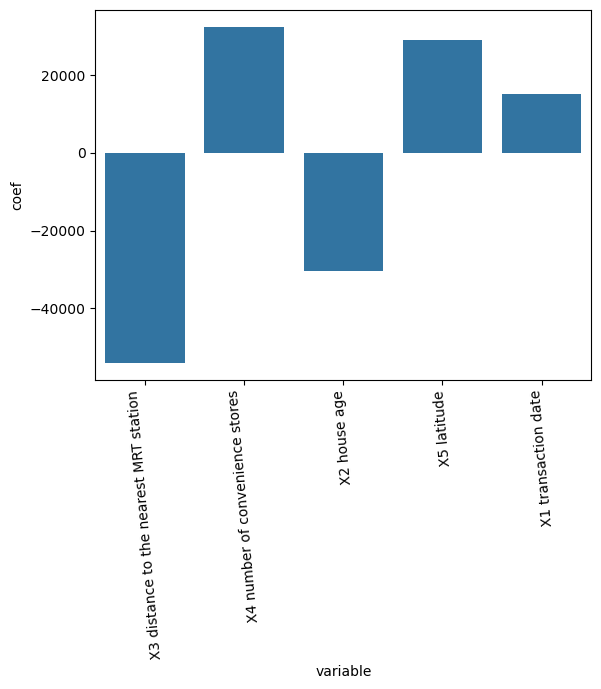

In [38]:
view_coeff(X ,linear_step)

In [39]:

#RIDGE MODEL

ridgemodel = Pipeline([
    ('s', StandardScaler()),
    ('model', RidgeCV())
])
ridge_step = ridgemodel.named_steps['model']

ridgemodel.fit(X_train,y_train)
ridge_pred = ridgemodel.predict(X_test)
coef_df_r3 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_step.coef_
})

print(coef_df_r3)
rmse_r3 = np.sqrt(mean_squared_error(y_test, ridge_pred))
mae_r3 = mean_absolute_error(y_test, ridge_pred)
r2_r3 = r2_score(y_test, ridge_pred)

print(f"RMSE: {rmse_r3:.3f}")
print(f"MAE: {mae_r3:.3f}")
print(f"R²: {r2_r3:.3f}")

                                  Feature   Coefficient
0                     X1 transaction date  14653.584154
1                            X2 house age -29649.880199
2  X3 distance to the nearest MRT station -52469.088093
3         X4 number of convenience stores  32335.616333
4                             X5 latitude  28929.040618
RMSE: 72823.408
MAE: 52978.788
R²: 0.684


In [40]:
#LASSO MODEL
lassomodel = Pipeline([
    ('s', StandardScaler()),
    ('model', Lasso())
])

lasso_step = lassomodel.named_steps['model']

lassomodel.fit(X_train,y_train)
lasso_pred = lassomodel.predict(X_test)
coef_df_lasso3 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_step.coef_
})

print(coef_df_lasso3)
rmse_lasso3 = np.sqrt(mean_squared_error(y_test, lasso_pred))
mae_lasso3 = mean_absolute_error(y_test, lasso_pred)
r2_lasso3 = r2_score(y_test, lasso_pred)

print(f"RMSE: {rmse_lasso3:.3f}")
print(f"MAE: {mae_lasso3:.3f}")
print(f"R²: {r2_lasso3:.3f}")

                                  Feature   Coefficient
0                     X1 transaction date  15214.664994
1                            X2 house age -30506.139579
2  X3 distance to the nearest MRT station -54024.588883
3         X4 number of convenience stores  32433.485436
4                             X5 latitude  28901.162494
RMSE: 72911.844
MAE: 52970.579
R²: 0.683


No long
Linear r2 : 0.683
Ridge r2 : 0.684
Lasso r2 : 0.667

Seems like longitude doesnt add anything since results are very close to not removing any info

Note tried running model multiple times without random state model r2 score seems to change between the 0.3 and 0.7 areas 
rather there isnt enough data for consistent results or the variables dont relate to the price of the house sold as much as they should

Gonna try make it so that it only shows the year and not the rest of the dates cause maybe it effects the model

multiplied the price of unit by 10000 since for some reason the units in the data are 10000 ping only seemed to effect lasso positivley 

No transaction date this time doesnt seem to effect data that much 

In [41]:
X = df.drop(['Y house price of unit area', 'No','X1 transaction date'], axis = 1)
y = df['Y house price of unit area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2 ,random_state=42 )

In [42]:

#LINMODEL

linmodel = Pipeline([
    ('s', StandardScaler()),
    ('model', LinearRegression())
])
linear_step = linmodel.named_steps['model']
linmodel.fit(X_train,y_train)
lin_pred = linmodel.predict(X_test)
coef_df_lin3 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_step.coef_
})

print(coef_df_lin3)
rmse_lin3 = np.sqrt(mean_squared_error(y_test, lin_pred))
mae_lin3 = mean_absolute_error(y_test, lin_pred)
r2_lin3 = r2_score(y_test, lin_pred)

print(f"RMSE: {rmse_lin3:.3f}")
print(f"MAE: {mae_lin3:.3f}")
print(f"R²: {r2_lin3:.3f}")

                                  Feature  Coefficient
0                            X2 house age    -3.060452
1  X3 distance to the nearest MRT station    -5.536238
2         X4 number of convenience stores     3.259264
3                             X5 latitude     2.942986
4                            X6 longitude    -0.357437
RMSE: 7.388
MAE: 5.350
R²: 0.675


In [43]:
#RIDGE MODEL

ridgemodel = Pipeline([
    ('s', StandardScaler()),
    ('model', RidgeCV())
])
ridge_step = ridgemodel.named_steps['model']

ridgemodel.fit(X_train,y_train)
ridge_pred = ridgemodel.predict(X_test)
coef_df_r3 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_step.coef_
})

print(coef_df_r3)
rmse_r3 = np.sqrt(mean_squared_error(y_test, ridge_pred))
mae_r3 = mean_absolute_error(y_test, ridge_pred)
r2_r3 = r2_score(y_test, ridge_pred)

print(f"RMSE: {rmse_r3:.3f}")
print(f"MAE: {mae_r3:.3f}")
print(f"R²: {r2_r3:.3f}")

                                  Feature  Coefficient
0                            X2 house age    -2.964666
1  X3 distance to the nearest MRT station    -5.101752
2         X4 number of convenience stores     3.262009
3                             X5 latitude     2.963094
4                            X6 longitude    -0.016442
RMSE: 7.367
MAE: 5.356
R²: 0.677


In [44]:
#LASSO MODEL
lassomodel = Pipeline([
    ('s', StandardScaler()),
    ('model', Lasso())
])

lasso_step = lassomodel.named_steps['model']

lassomodel.fit(X_train,y_train)
lasso_pred = lassomodel.predict(X_test)
coef_df_lasso3 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_step.coef_
})

print(coef_df_lasso3)
rmse_lasso3 = np.sqrt(mean_squared_error(y_test, lasso_pred))
mae_lasso3 = mean_absolute_error(y_test, lasso_pred)
r2_lasso3 = r2_score(y_test, lasso_pred)

print(f"RMSE: {rmse_lasso3:.3f}")
print(f"MAE: {mae_lasso3:.3f}")
print(f"R²: {r2_lasso3:.3f}")

                                  Feature  Coefficient
0                            X2 house age    -2.002822
1  X3 distance to the nearest MRT station    -5.011240
2         X4 number of convenience stores     2.633145
3                             X5 latitude     2.338110
4                            X6 longitude     0.000000
RMSE: 7.541
MAE: 5.676
R²: 0.661


Trying to use foward feature selection 

In [45]:
X = df.drop(['Y house price of unit area', 'No'], axis = 1)
y = df['Y house price of unit area'] 


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state=42)

In [47]:

# start with no predictors
included = []

# keep track of model and parameters
best = {'feature': '', 'r2': 0, 'a_r2': 0}
# create a model object to hold the modelling parameters
model = LinearRegression()
# get the number of cases in the training data
n = X_train.shape[0]

r2_list = []
adjusted_r2_list = []

while True:
    changed = False
    excluded = list(set(X_train.columns) - set(included))

    best_candidate = {'feature': None, 'r2': 0, 'a_r2': 0}

    for new_column in excluded:
        # Fit model
        model.fit(X_train[included + [new_column]], y_train)

        # Evaluate
        r2 = model.score(X_test[included + [new_column]], y_test)

        k = len(included + [new_column]) + 1
        adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

        # Track best feature in THIS iteration
        if adjusted_r2 > best_candidate['a_r2']:
            best_candidate = {
                'feature': new_column,
                'r2': r2,
                'a_r2': adjusted_r2
            }

    # After testing all features
    if best_candidate['a_r2'] > best['a_r2']:
        included.append(best_candidate['feature'])
        best = best_candidate

        r2_list.append(best['r2'])
        adjusted_r2_list.append(best['a_r2'])

        print(f"Added {best['feature']} | R2: {best['r2']:.3f} | Adj R2: {best['a_r2']:.3f}")
        changed = True

    if not changed:
        break

Added X3 distance to the nearest MRT station | R2: 0.539 | Adj R2: 0.536
Added X4 number of convenience stores | R2: 0.605 | Adj R2: 0.601
Added X2 house age | R2: 0.649 | Adj R2: 0.645
Added X5 latitude | R2: 0.676 | Adj R2: 0.671
Added X1 transaction date | R2: 0.683 | Adj R2: 0.677


In [48]:

# start with no predictors
included = []

# keep track of model and parameters
best = {'feature': '', 'r2': 0, 'a_r2': 0}
# create a model object to hold the modelling parameters
model = Lasso()
# get the number of cases in the training data
n = X_train.shape[0]

r2_list = []
adjusted_r2_list = []

while True:
    changed = False
    excluded = list(set(X_train.columns) - set(included))

    best_candidate = {'feature': None, 'r2': 0, 'a_r2': 0}

    for new_column in excluded:
        # Fit model
        model.fit(X_train[included + [new_column]], y_train)

        # Evaluate
        r2 = model.score(X_test[included + [new_column]], y_test)

        k = len(included + [new_column]) + 1
        adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

        # Track best feature in THIS iteration
        if adjusted_r2 > best_candidate['a_r2']:
            best_candidate = {
                'feature': new_column,
                'r2': r2,
                'a_r2': adjusted_r2
            }

    # After testing all features
    if best_candidate['a_r2'] > best['a_r2']:
        included.append(best_candidate['feature'])
        best = best_candidate

        r2_list.append(best['r2'])
        adjusted_r2_list.append(best['a_r2'])

        print(f"Added {best['feature']} | R2: {best['r2']:.3f} | Adj R2: {best['a_r2']:.3f}")
        changed = True

    if not changed:
        break

Added X3 distance to the nearest MRT station | R2: 0.539 | Adj R2: 0.536
Added X4 number of convenience stores | R2: 0.600 | Adj R2: 0.597
Added X2 house age | R2: 0.645 | Adj R2: 0.641


In [49]:

# start with no predictors
included = []

# keep track of model and parameters
best = {'feature': '', 'r2': 0, 'a_r2': 0}
# create a model object to hold the modelling parameters
model = RidgeCV()
# get the number of cases in the training data
n = X_train.shape[0]

r2_list = []
adjusted_r2_list = []

while True:
    changed = False
    excluded = list(set(X_train.columns) - set(included))

    best_candidate = {'feature': None, 'r2': 0, 'a_r2': 0}

    for new_column in excluded:
        # Fit model
        model.fit(X_train[included + [new_column]], y_train)

        # Evaluate
        r2 = model.score(X_test[included + [new_column]], y_test)

        k = len(included + [new_column]) + 1
        adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

        # Track best feature in THIS iteration
        if adjusted_r2 > best_candidate['a_r2']:
            best_candidate = {
                'feature': new_column,
                'r2': r2,
                'a_r2': adjusted_r2
            }

    # After testing all features
    if best_candidate['a_r2'] > best['a_r2']:
        included.append(best_candidate['feature'])
        best = best_candidate

        r2_list.append(best['r2'])
        adjusted_r2_list.append(best['a_r2'])

        print(f"Added {best['feature']} | R2: {best['r2']:.3f} | Adj R2: {best['a_r2']:.3f}")
        changed = True

    if not changed:
        break

Added X3 distance to the nearest MRT station | R2: 0.539 | Adj R2: 0.536
Added X4 number of convenience stores | R2: 0.605 | Adj R2: 0.601
Added X2 house age | R2: 0.649 | Adj R2: 0.645
Added X1 transaction date | R2: 0.665 | Adj R2: 0.660
Added X5 latitude | R2: 0.675 | Adj R2: 0.669


In [50]:
X = df.drop(['Y house price of unit area', 'No'], axis = 1)
y = df['Y house price of unit area'] 


In [51]:
#RIDGE MODEL
ridgemodel = Pipeline([
    ('s', StandardScaler()),
    ('model', RidgeCV())
])
ridge_step = ridgemodel.named_steps['model']

ridgemodel.fit(X_train,y_train)
ridge_pred = ridgemodel.predict(X_test)
coef_df_r2 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_step.coef_
})

print(coef_df_r2)
rmse_r2 = np.sqrt(mean_squared_error(y_test, ridge_pred))
mae_r2 = mean_absolute_error(y_test, ridge_pred)
r2_r2 = r2_score(y_test, ridge_pred)

print(f"RMSE: {rmse_r2:.3f}")
print(f"MAE: {mae_r2:.3f}")
print(f"R²: {r2_r2:.3f}")

                                  Feature  Coefficient
0                     X1 transaction date     1.466623
1                            X2 house age    -2.967250
2  X3 distance to the nearest MRT station    -5.309401
3         X4 number of convenience stores     3.231093
4                             X5 latitude     2.888470
5                            X6 longitude    -0.076175
RMSE: 7.286
MAE: 5.295
R²: 0.684


In [52]:
r2 = ridgemodel.score(X_test, y_test)
n, p = X.shape

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2

0.6789275470166495

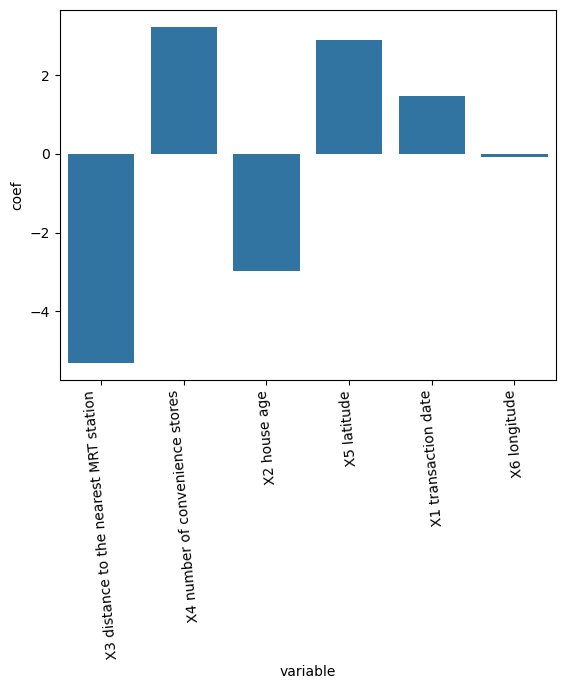

In [53]:
view_coeff(X ,ridge_step)

Seems like ridge with all features seems to be ever so slightly better after foward feature selection missed it

Text(0, 0.5, 'Predicted value')

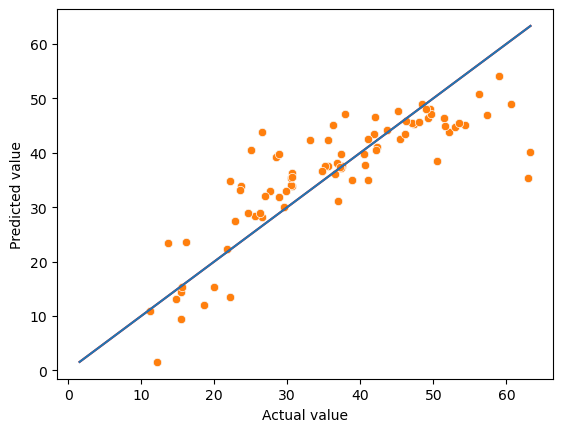

In [54]:
ridge_pred = ridgemodel.predict(X_test)
min_val = min(y_test.min(), ridge_pred.min())
max_val = max(y_test.max(), ridge_pred.max())

x1 = np.linspace(min_val, max_val, 100)
y1 = x1

sns.scatterplot(x=y_test, y=ridge_pred)
sns.lineplot(x=x1, y=y1, color='red')  # y = x line

sns.scatterplot(x = y_test, y = ridge_pred )
sns.lineplot(x = x1, y = y1)
plt.xlabel('Actual value')
plt.ylabel('Predicted value')
